In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Notebook illustrates
- loading mseed data
- building an inventory and remove instrument response
- plot seismogram
- compute spectrogram
- plot spectrogram

@ daniel binder
Golm, 09.06.2026
"""

import numpy as np
import pandas as pd
import scipy.signal

from obspy import read, read_inventory, Stream
from obspy import UTCDateTime

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set plot parameters
plt.rcParams.update({
    'font.size': 14,        
    'axes.titlesize': 28,   
    'axes.labelsize': 28,   
    'xtick.labelsize': 20,  
    'ytick.labelsize': 20,  
    'legend.fontsize': 20  
})

# --- PARAMETERS ---
base_dir = Path("/media/db/DB_2TBext4/up_env_seismology")
data_dir = base_dir / '01_data/ap23'
station = '456'
station_dir = data_dir / station

# check https://ds.iris.edu/ds/nrl/datalogger/digosomnirecs/datacube/ for datacube response fct
address = data_dir / 'digos_datacube_400Hz_32amp.xml'

# define the scaling factor for the STEIM2 conversion
sc = 1e9

In [2]:
#find all datacube files in the station folder
mseed_files = [str(file) for file in station_dir.glob("*.pri0")]

files = sorted(mseed_files)

# Print results to be sure that it is sorted by day
for file in files:
    print(file)


/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230701000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230702000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230703000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230704000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230705000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230706000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230707000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230708000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230709000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230710000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230711000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/456/c0456230712000000.pri0
/media/db/DB_2TBext4/up_env_seismology/01_data/ap23/

In [3]:
# Setup your inventory metadata mapping parameters
# network, station, location, channel = 'XX', 'YY', '00', 'ZZZ'

# Load inventory file once
inv = read_inventory(address)
inv.code = 'XX'
inv.code = 'YY'
inv.location_code = '00'
inv.code = 'ZZZ'

# Create a master stream to collect final processed data 
# OR save them to disk directly inside the loop to use ZERO extra RAM
st = Stream()

print("Processing each trace individually...")

for file_path in files:
    try:
        # Load one single day file into memory
        st_day = read(file_path)
        
        # Match metadata strings for response attachment
        for tr in st_day:
            tr.stats.network = 'XX'
            tr.stats.station = 'YY'
            tr.stats.location = '00'
            tr.stats.channel = 'ZZZ'
        
        # Attach and remove instrument response
        st_day.attach_response(inv)
        st_day.remove_response(output="VEL", water_level=60) # standard safety threshold
          
        # Explicitly cast data to 32-bit float and match the MiniSEED encoding tag to avoid Warning
        for tr in st_day:
            tr.data = tr.data.astype(np.float32)
            tr.stats.mseed = {'encoding': 'FLOAT32'}      
               
        # Collect into memory for downstream code
        st += st_day

        print(f"Successfully processed and added to the datastream: {file_path.split('/')[-1]}")

        # Save to disk for later use
        # need to scale and convert to integers to apply STEIM2 compression
        # REMEMBER SCALING BACK WHEN READING BACK IN!
        for tr in st_day:
            # Scale by 10^9 converts velocity from m/s to nm/s so decimals are not rounded to 0
            tr.data = (tr.data * sc).astype(np.int32)
            
            # Explicitly reset the metadata container to handle STEIM2 compression
            tr.stats.mseed = {'encoding': 'STEIM2'} 
        
        output_name = file_path.replace(".pri0", "_corrected_scaled_1e9.mseed")
        st_day.write(output_name, format="MSEED", encoding='STEIM2')

        
    except Exception as e:
        print(f"Skipping file {file_path} due to error: {e}")
        continue

print("\nInstrument response successfully removed for all files.")

Processing each trace individually...
Successfully processed and added to the datastream: c0456230701000000.pri0
Successfully processed and added to the datastream: c0456230702000000.pri0
Successfully processed and added to the datastream: c0456230703000000.pri0
Successfully processed and added to the datastream: c0456230704000000.pri0
Successfully processed and added to the datastream: c0456230705000000.pri0
Successfully processed and added to the datastream: c0456230706000000.pri0
Successfully processed and added to the datastream: c0456230707000000.pri0
Successfully processed and added to the datastream: c0456230708000000.pri0
Successfully processed and added to the datastream: c0456230709000000.pri0
Successfully processed and added to the datastream: c0456230710000000.pri0
Successfully processed and added to the datastream: c0456230711000000.pri0
Successfully processed and added to the datastream: c0456230712000000.pri0
Successfully processed and added to the datastream: c045623071

In [4]:
# Continue here in case you already removed the instrument response and did save the corrected files
cor_mseed_files = [str(file) for file in station_dir.glob("*.mseed")]
cor_files = sorted(cor_mseed_files)

st = Stream()

for file_path in cor_files:
    try:
        # Load one single day file into memory
        st_day = read(file_path)
        
        # Scale back the data
        for tr in st_day:
            tr.data = tr.data / sc
               
        # Collect into memory for downstream code
        st += st_day

        print(f"Successfully loaded, rescaled and added to the datastream: {file_path.split('/')[-1]}")

    except Exception as e:
        print(f"Skipping file {file_path} due to error: {e}")
        continue


Successfully loaded, rescaled and added to the datastream: c0456230701000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456230702000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456230703000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456230704000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456230705000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456230706000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456230707000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456230708000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456230709000000_corrected_scaled_1e9.mseed
Successfully loaded, rescaled and added to the datastream: c0456

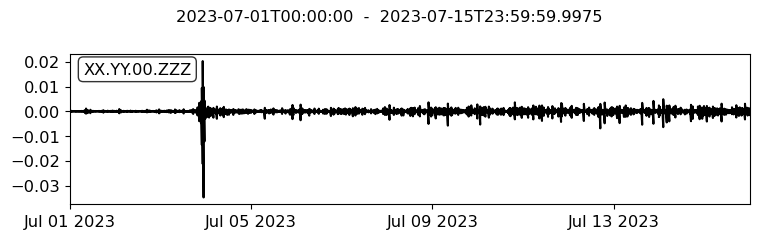

'\n# Grab the axis to customize formatting\nax = fig.gca()\nax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.\n%H:%M"))\nax.grid(True, color=\'gray\', linestyle=\':\')\n\nax.set_title(f"Station {station}")\n\nplt.show()\n'

In [5]:
# Plot seismogram

# Define your start and end datetime
#start = UTCDateTime("2023-07-01T08:00:00")
#end = UTCDateTime("2023-07-01T12:00:00")

fig = st.plot(
#    starttime=start,
#    endtime=end,
    handle=False,  
    color='black', 
    linewidth=0.5
)

'''
# Grab the axis to customize formatting
ax = fig.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.\n%H:%M"))
ax.grid(True, color='gray', linestyle=':')

ax.set_title(f"Station {station}")

plt.show()
'''

In [6]:
# Compute spectrogram

# Before looping over the traces define Welch parameters
# Get sampling rate from stream
sps = st[0].stats.sampling_rate

# Primary time window size for the Welch function (e.g., 30 minutes = 1800 seconds)
window_duration_min = 30
window_duration_sec = window_duration_min * 60  
n = int(window_duration_sec * sps)  # Samples per primary window

# Internal Welch sub-segment settings
nperseg = int(n // 6)       # Length of internal sub-segments
noverlap = int(nperseg // 2) # Overlap between internal sub-segments (e.g., 50%)

# Initiate master lists
all_psds = []
all_times = []

# Loop over traces inside your existing stream object
for tr in st:
    try:
        # Skip tiny gap segments that are shorter than 1 hour
        if len(tr.data) < n:
            continue
            
        # Extract start date parameters directly from the trace metadata
        day_start = pd.Timestamp(tr.stats.starttime.datetime)

        # Compute Welch matrices for this specific trace array
        # Continuous data is shaped into a 2D matrix: [num_windows, n]
        num_windows = len(tr.data) // n  
        signal_windows = np.array([tr.data[i * n: (i + 1) * n] for i in range(num_windows)])

        # axis=1 forces SciPy to calculate the PSD for each time window independently
        f, psd = scipy.signal.welch(
            signal_windows, 
            fs=sps, 
            nperseg=nperseg, 
            noverlap=noverlap, 
            scaling='density',
            axis=1
        )
        
       # Generate a timestamp for each window center point
        num_windows_processed = psd.shape[0]
        day_times = [
            day_start + pd.Timedelta(minutes=(i * window_duration_min) + (window_duration_min / 2)) 
            for i in range(num_windows_processed)
        ]

        # Append results to master lists
        all_psds.append(psd)
        all_times.extend(day_times)
        
        print(f"Computed PSD for period {tr.stats.starttime} to {tr.stats.endtime}")
        
    except Exception as e:
        print(f"Skipping trace {tr.id} due to calculation error: {e}")
        continue
        
# Combine masters
master_psd = np.concatenate(all_psds, axis=0)  # Shape: (total_hours, frequency_bins)
master_times = np.array(all_times, dtype='datetime64[ns]')

# Save masters
# Create storage path
proc_data_dir = base_dir / '02_processed_data/ap23'
proc_data_dir.mkdir(parents=True, exist_ok=True)

# Create filename
npz_fn = (
    str(station)+
    '_'+
    str(st[0].stats.starttime.year)+
    str(st[0].stats.starttime.month).zfill(2)+
    str(st[0].stats.starttime.day).zfill(2) +
    '_'+ 
    str(st[-1].stats.endtime.month).zfill(2)+
    str(st[-1].stats.endtime.day).zfill(2)+
    '.npz'
)

save_path = proc_data_dir / npz_fn

# Save all components into a compressed file
np.savez_compressed(
    save_path, 
    psd=master_psd, 
    times=master_times, 
    frequencies=f
)

print(f"\nData successfully saved to: {save_path}")

Computed PSD for period 2023-07-01T00:00:00.000000Z to 2023-07-01T23:59:59.997500Z
Computed PSD for period 2023-07-02T00:00:00.000000Z to 2023-07-02T23:59:59.997500Z
Computed PSD for period 2023-07-03T00:00:00.000000Z to 2023-07-03T23:59:59.997500Z
Computed PSD for period 2023-07-04T00:00:00.000000Z to 2023-07-04T23:59:59.997500Z
Computed PSD for period 2023-07-05T00:00:00.000000Z to 2023-07-05T23:59:59.997500Z
Computed PSD for period 2023-07-06T00:00:00.000000Z to 2023-07-06T23:59:59.997500Z
Computed PSD for period 2023-07-07T00:00:00.000000Z to 2023-07-07T23:59:59.997500Z
Computed PSD for period 2023-07-08T00:00:00.000000Z to 2023-07-08T23:59:59.997500Z
Computed PSD for period 2023-07-09T00:00:00.000000Z to 2023-07-09T23:59:59.997500Z
Computed PSD for period 2023-07-10T00:00:00.000000Z to 2023-07-10T23:59:59.997500Z
Computed PSD for period 2023-07-11T00:00:00.000000Z to 2023-07-11T23:59:59.997500Z
Computed PSD for period 2023-07-12T00:00:00.000000Z to 2023-07-12T23:59:59.997500Z
Comp

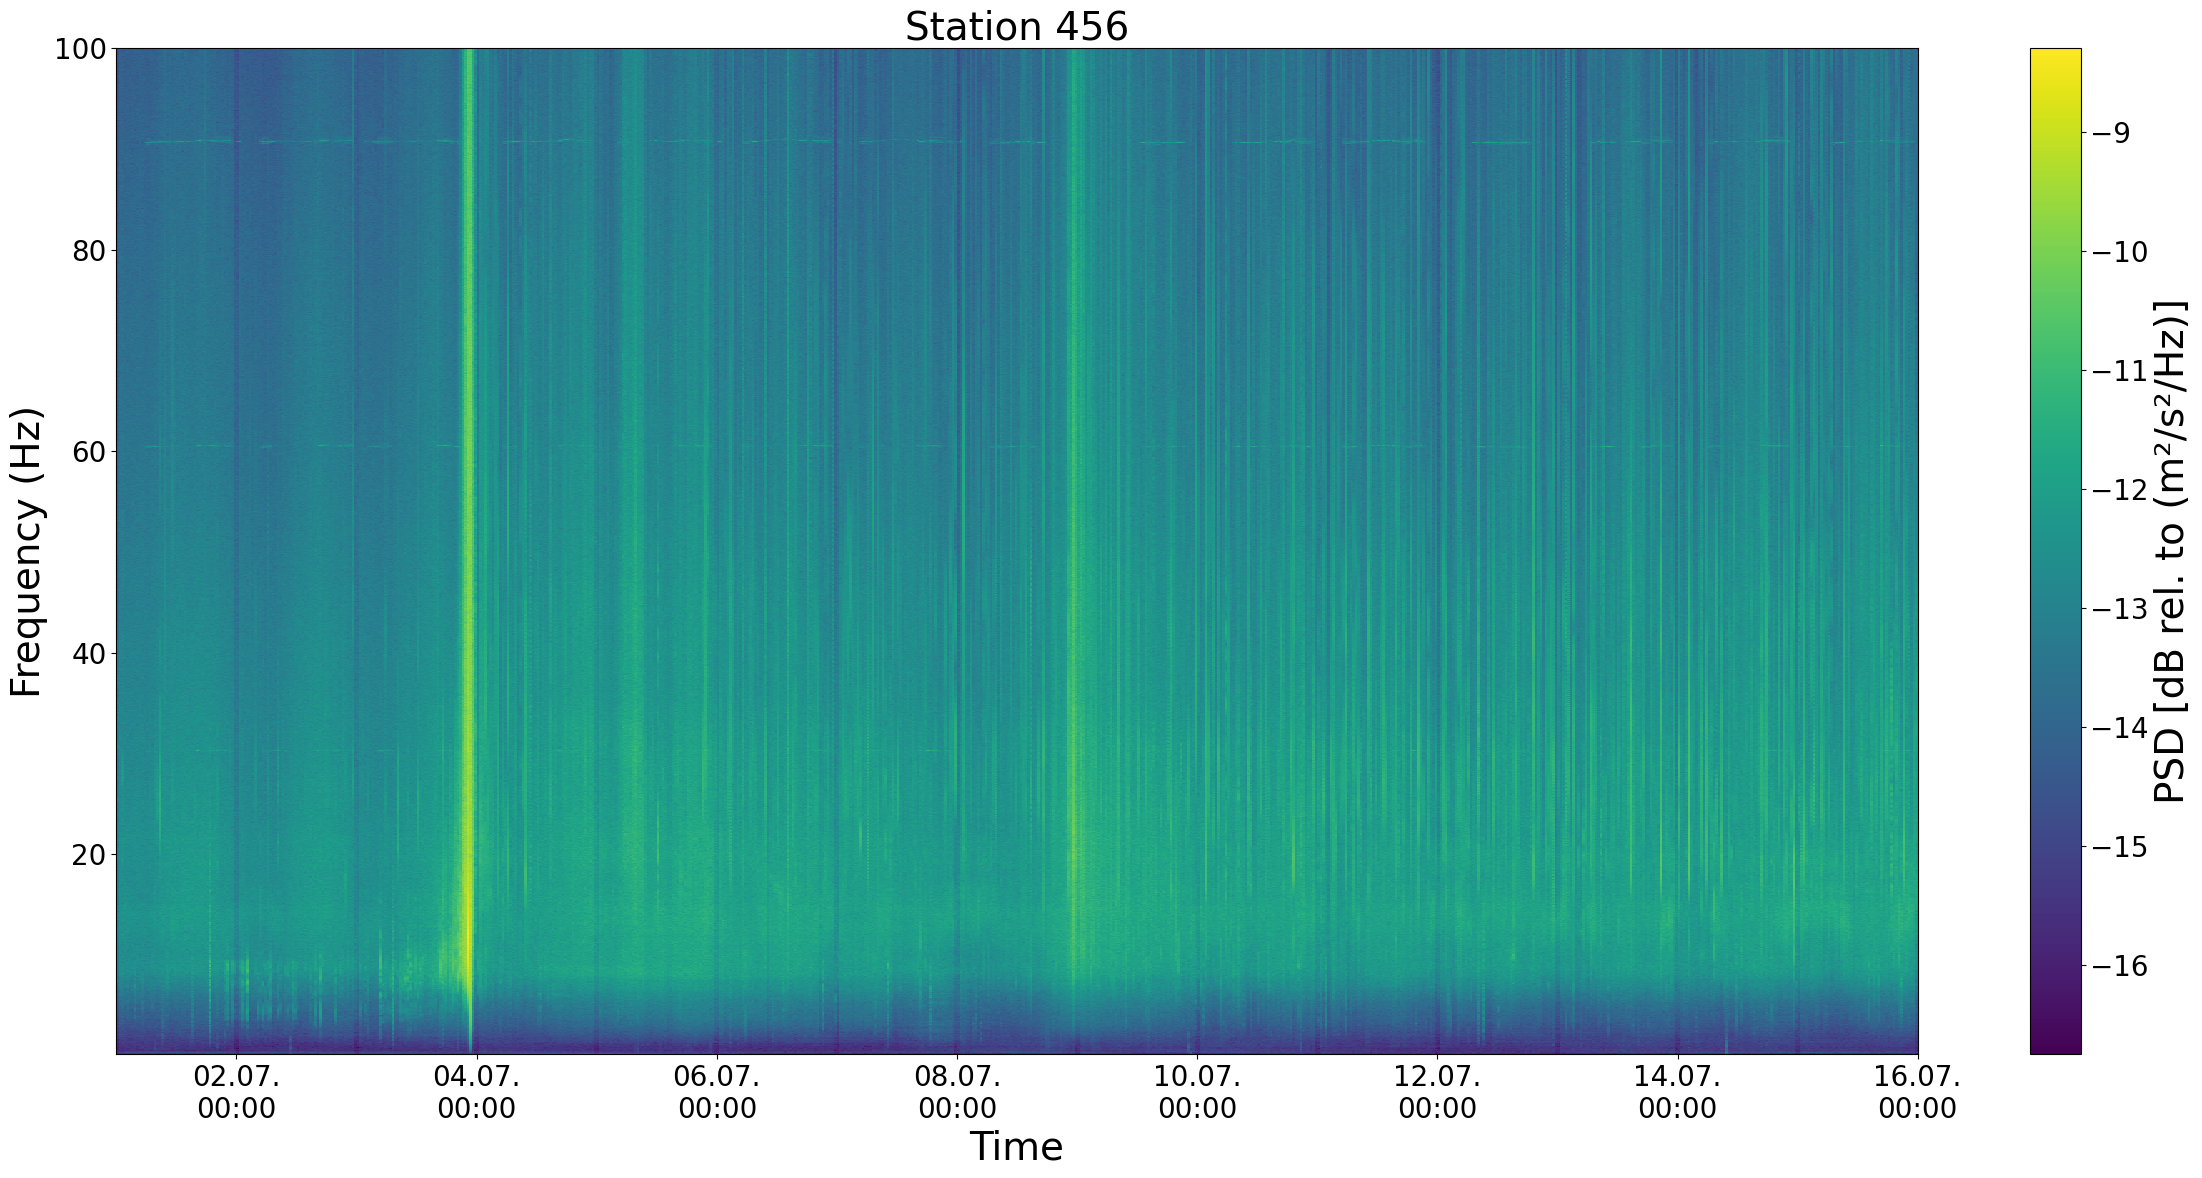

In [7]:
# Plot spectrogram
fig, ax = plt.subplots(figsize=(24, 12))

# Plot time array against frequency matrix. Transpose (.T) is needed to match pcolormesh axis structure.
pcm = ax.pcolormesh(
    master_times, 
    f, 
    np.log10(master_psd.T),
    cmap='viridis', 
    shading='nearest'
)

# Format colorbar
cbar = fig.colorbar(
    pcm, 
    ax=ax, 
    label='PSD [dB rel. to (m²/s²/Hz)]'
)

# Format axes and dates
ax.set_ylim(0.1, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.\n%H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2)) 
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time")
ax.set_title(f"Station {station}")
plt.tight_layout()

# if not there create figures directory
figures_dir = base_dir / '03_figures/ap23'
figures_dir.mkdir(parents=True, exist_ok=True)

# replace extension for png figure
png_fn = npz_fn.replace('.npz', '.png')

plt.savefig(figures_dir / png_fn, dpi = 300)

plt.show()